In [21]:
import re
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
import os

In [22]:
class Account:
    __account_counter: int = 1000
    holder: str
    account_number: str
    __balance: float
    operations_history: list[dict]
        
    def __init__(self, account_holder: str, balance: float =0, account_number: str | None = None):
        self.holder_set(account_holder)
        
        if account_number is None:
            self.account_number = f"ACC-{Account.__account_counter}"
            Account.__account_counter += 1
        else:
            self.account_number = account_number
        
        if balance < 0:
            raise ValueError("Начальный баланс не может быть отрицательным")
        self.__balance = balance
        self.operations_history = []
        
    def holder_set(self, owner: str) -> None:
        owner_pattern = r'^[A-ZА-ЯЁ][a-zа-яё]+ [A-ZА-ЯЁ][a-zа-яё]+$'
        if not re.match(owner_pattern, owner):
            raise ValueError("Имя владельца должно быть в формате 'Имя Фамилия'")
        self.holder = owner
        
    def __add_operation(self, op_type: str, amount: float, status: str, comment: str = "") -> None:
        operation = {
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "type": op_type,
            "amount": amount,
            "balance": self.__balance,
            "status": status,
            "comment": comment
        }
        self.operations_history.append(operation)
        
    def deposit(self, amount: float) -> None:
        if amount <= 0:
            raise ValueError("Сумма должна быть положительной")
        
        self.__balance += amount
        self.__balance = round(self.__balance, 2)    
        self.__add_operation("deposit", amount, "success")
        
    def withdraw(self, amount: float) -> None:
        if amount <= 0:
            raise ValueError("Сумма должна быть положительной")
        
        if self.__balance - amount < 0:
            self.__add_operation("withdraw", amount, "error", "Недостаточно средств")
        else:
            self.__balance -= amount
            self.__balance = round(self.__balance, 2)
            self.__add_operation("withdraw", amount, "success")
            
    def get_history(self) -> list[dict]:
        return self.operations_history
    
    def print_history(self) -> None:
        for op in self.operations_history:
            print(f"{op['timestamp']} | {op['type']:8} | {op['amount']:10.2f} | "
                  f"{op['balance']:10.2f} | {op['status']:7} | {op['comment']}")
            
    def get_balance(self) -> float:
        return self.__balance
    
    def _parse_timestamp(self, ts: str) -> datetime | None:
        formats = ["%Y-%m-%d %H:%M:%S", "%d/%m/%Y %H:%M"]
        for fmt in formats:
            try:
                return datetime.strptime(ts, fmt)
            except ValueError:
                continue
        return None
    
    def clean_history(self, raw_records: list[dict]) -> list[dict]:
        cleaned: list[dict] = []

        for record in raw_records:
            # 1. Проверяем, что это операции именно этого счёта
            if record.get("account_number") != self.account_number:
                continue

            # 2. Проверяем тип операции
            operation = record.get("operation")
            if operation not in self.ALLOWED_OPERATIONS:
                continue

            # 3. Проверяем и нормализуем сумму
            try:
                amount = float(record.get("amount"))
            except (TypeError, ValueError):
                continue
            # отбрасываем NaN и неположительные суммы
            if math.isnan(amount) or amount <= 0:
                continue

            # 4. Проверяем и нормализуем дату
            raw_ts = record.get("date")
            dt = self._parse_timestamp(raw_ts)
            if dt is None:
                continue

            # 5. Собираем нормализованную запись (копируем исходную)
            normalized = record.copy()
            normalized["amount"] = amount
            normalized["timestamp"] = dt.strftime("%Y-%m-%d %H:%M:%S")

            cleaned.append(normalized)

        return cleaned
    
    def load_history_from_file(self, filepath: str) -> None:
        _, ext = os.path.splitext(filepath)

        if ext == ".json":
            with open(filepath, "r", encoding="utf-8") as f:
                raw_records = json.load(f)
        elif ext == ".csv":
            df = pd.read_csv(filepath)
            raw_records = df.to_dict(orient="records")
        else:
            raise ValueError("Поддерживаются только файлы .csv и .json")

        cleaned_records = self.clean_history(raw_records)

        for rec in cleaned_records:
            self._apply_clean_operation(rec)
    
    def analyze_history(self, n: int = 5) -> list[dict]:
        successful_ops = [op for op in self.operations_history if op["status"] == "success"]
        # Сначала сортируем по размеру, потом по дате - оба по убыванию
        top_ops = sorted(
            successful_ops, 
            key=lambda x: (x["amount"], x["timestamp"]), 
            reverse=True
        )[:n]
        
        return top_ops
    
    def plot_history(self) -> None:
        if not self.operations_history:
            print("История операций пуста, нечего визуализировать.")
            return
        
        df = pd.DataFrame(self.operations_history)
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        df = df.sort_values("timestamp")
        df = df.sort_values("timestamp").reset_index(drop=True)
        
        plt.figure(figsize=(10, 5))
        plt.plot(range(len(df)), df["balance"], marker="o", linestyle="-")
        plt.xticks(ticks=range(len(df)), labels=df["timestamp"].dt.strftime("%Y-%m-%d %H:%M:%S"), rotation=45, ha="right")
        plt.title(f"Изменение баланса по счёту {self.account_number}")
        plt.xlabel("Время операции")
        plt.ylabel("Баланс")
        plt.tight_layout()
        plt.show()

In [23]:
class SavingsAccount(Account):
    account_type: str = "Savings"
    ALLOWED_OPERATIONS = {"deposit", "withdraw", "interest"}
    
    def withdraw(self, amount: float) -> None:
        if amount <= 0:
            raise ValueError("Сумма должна быть положительной")
        
        if amount > 0.5 * self.get_balance():
            self._Account__add_operation("withdraw", amount, "error", "Превышен лимит 50% от баланса")
            return
        
        self._Account__balance -= amount
        self._Account__balance = round(self._Account__balance, 2)
        self._Account__add_operation("withdraw", amount, "success")
        
    def apply_interest(self, rate: float) -> None:
        if rate <= 0:
            raise ValueError("Ставка должна быть положительной")
        
        self._Account__balance *= (1 + rate / 100)
        self._Account__balance = round(self._Account__balance, 2)
        self._Account__add_operation("interest", 0, "success", f"Начислены проценты {rate}%")
        
    def _apply_clean_operation(self, record: dict) -> None:
        op_type = record["operation"]
        amount = record["amount"]
        timestamp = record["timestamp"]

        old_balance = self.get_balance()

        if op_type == "deposit":
            new_balance = old_balance + amount

        elif op_type == "withdraw":
            if amount > 0.5 * old_balance:
                operation = {
                    "timestamp": timestamp,
                    "type": op_type,
                    "amount": amount,
                    "balance": old_balance,
                    "status": "error",
                    "comment": "Превышен лимит 50% (загрузка из файла)"
                }
                self.operations_history.append(operation)
                return
            new_balance = old_balance - amount

        elif op_type == "interest":
            # здесь считаем, что amount — уже начисленные проценты
            new_balance = old_balance + amount

        else:
            return

        self._Account__balance = new_balance
        self._Account__balance = round(new_balance, 2)

        operation = {
            "timestamp": timestamp,
            "type": op_type,
            "amount": amount,
            "balance": new_balance,
            "status": "success",
            "comment": "loaded from file"
        }
        self.operations_history.append(operation)

In [24]:
class CheckingAccount(Account):
    account_type: str = "Checking"
    ALLOWED_OPERATIONS = {"deposit", "withdraw"}
        
    def _apply_clean_operation(self, record: dict) -> None:
        op_type = record["operation"]
        amount = record["amount"]
        timestamp = record["timestamp"]

        old_balance = self.get_balance()

        if op_type == "deposit":
            new_balance = old_balance + amount
        elif op_type == "withdraw":
            if old_balance - amount < 0:
                operation = {
                    "timestamp": timestamp,
                    "type": op_type,
                    "amount": amount,
                    "balance": old_balance,
                    "status": "error",
                    "comment": "Недостаточно средств (загрузка из файла)"
                }
                self.operations_history.append(operation)
                return
            new_balance = old_balance - amount

        self._Account__balance = new_balance
        self._Account__balance = round(new_balance, 2)

        operation = {
            "timestamp": timestamp,
            "type": op_type,
            "amount": amount,
            "balance": new_balance,
            "status": "success",
            "comment": "loaded from file"
        }
        self.operations_history.append(operation)

=== SavingsAccount history ===
2025-11-09 06:28:31 | deposit  |     500.00 |    1500.00 | success | 
2025-11-09 06:28:31 | withdraw |     200.00 |    1300.00 | success | 
2025-11-09 06:28:31 | interest |       0.00 |    1430.00 | success | Начислены проценты 10%

Топ-3 операций по SavingsAccount:
{'timestamp': '2025-11-09 06:28:31', 'type': 'deposit', 'amount': 500, 'balance': 1500.0, 'status': 'success', 'comment': ''}
{'timestamp': '2025-11-09 06:28:31', 'type': 'withdraw', 'amount': 200, 'balance': 1300.0, 'status': 'success', 'comment': ''}
{'timestamp': '2025-11-09 06:28:31', 'type': 'interest', 'amount': 0, 'balance': 1430.0, 'status': 'success', 'comment': 'Начислены проценты 10%'}

=== CheckingAccount history ===
2025-11-09 06:28:31 | deposit  |     300.00 |     800.00 | success | 
2025-11-09 06:28:31 | withdraw |     200.00 |     600.00 | success | 
2025-11-09 06:28:31 | withdraw |    1000.00 |     600.00 | error   | Недостаточно средств

Топ-3 операций по CheckingAccount:
{'t

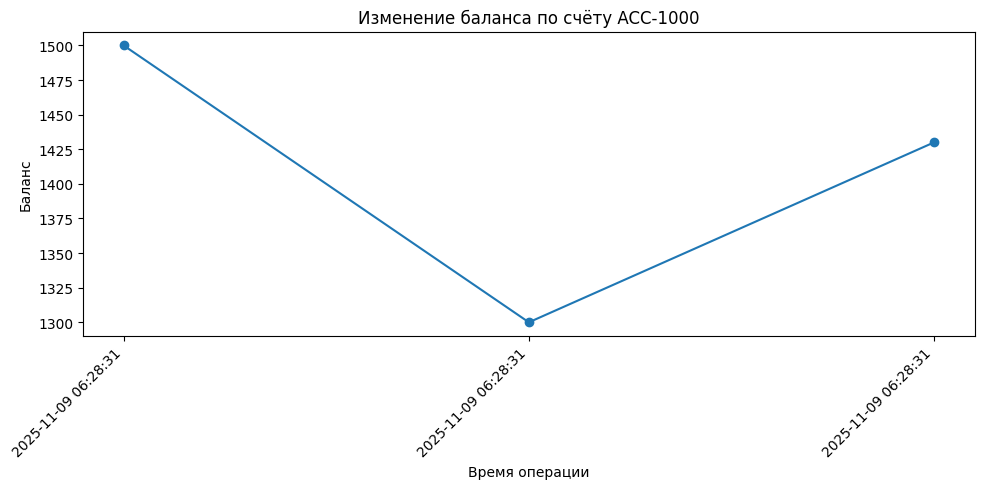

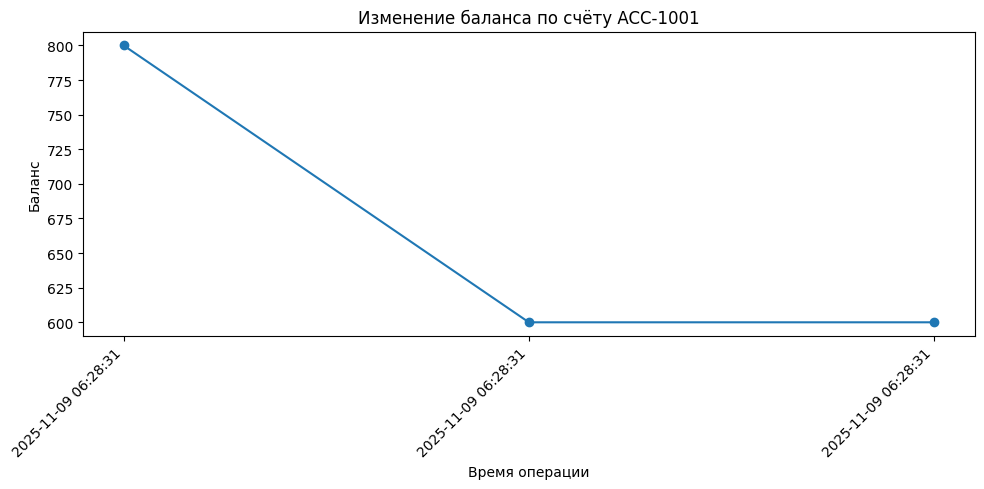

In [25]:
# Тесты для SavingsAccount и CheckingAccount

# Создаём счета
savings = SavingsAccount("Иван Иванов", 1000.0)
checking = CheckingAccount("Пётр Петров", 500.0)

# Операции по сберегательному счёту
savings.deposit(500)        # баланс: 1500
savings.withdraw(200)       # баланс: 1300
savings.apply_interest(10)  # баланс: 1430

# Операции по расчётному счёту
checking.deposit(300)     # пополнение баланс: 800
checking.withdraw(200)    # нормальное снятие баланс: 600
checking.withdraw(1000)   # попытка снять больше, чем есть (ошибка) баланс остаётся 600

print("=== SavingsAccount history ===")
savings.print_history()

print("\nТоп-3 операций по SavingsAccount:")
for op in savings.analyze_history(3):
    print(op)

print("\n=== CheckingAccount history ===")
checking.print_history()

print("\nТоп-3 операций по CheckingAccount:")
for op in checking.analyze_history(3):
    print(op)

print("\nБаланс SavingsAccount:", savings.get_balance())
print("Баланс CheckingAccount:", checking.get_balance())

# Графики изменения баланса
savings.plot_history()
checking.plot_history()


In [26]:
# Загрузка "грязных" данных для CheckingAccount

checking_from_file = CheckingAccount("Test Owner", 0.0, account_number="ACC-100001")

print("Счёт для загрузки истории:", checking_from_file.account_number)

# Загрузка истории из JSON
checking_from_file.load_history_from_file("files/transactions_dirty.json")

print("\n=== История после загрузки из JSON ===")
checking_from_file.print_history()
print("\nБаланс после загрузки из JSON:", checking_from_file.get_balance())

# Загрузка истории из CSV:
checking_from_file.load_history_from_file("files/transactions_dirty.csv")

print("\n=== История после дополнительной загрузки из CSV ===")
checking_from_file.print_history()
print("\nБаланс после загрузки из JSON + CSV:", checking_from_file.get_balance())


Счёт для загрузки истории: ACC-100001

=== История после загрузки из JSON ===
2025-09-27 22:17:26 | deposit  |     921.00 |     921.00 | success | loaded from file
2025-09-27 22:17:26 | deposit  |     607.00 |    1528.00 | success | loaded from file
2025-09-28 22:17:26 | deposit  |     488.00 |    2016.00 | success | loaded from file
2025-09-28 22:17:00 | deposit  |     129.00 |    2145.00 | success | loaded from file
2025-09-29 22:17:26 | deposit  |     880.00 |    3025.00 | success | loaded from file
2025-10-01 22:17:26 | withdraw |     352.00 |    2673.00 | success | loaded from file
2025-10-01 22:17:26 | withdraw |      65.00 |    2608.00 | success | loaded from file
2025-10-01 22:17:26 | withdraw |     245.00 |    2363.00 | success | loaded from file
2025-10-05 22:17:26 | deposit  |     327.00 |    2690.00 | success | loaded from file
2025-10-06 22:17:26 | withdraw |     333.00 |    2357.00 | success | loaded from file
2025-10-06 22:17:00 | withdraw |     198.00 |    2159.00 | suc

Счёт для загрузки истории (Savings): ACC-100002

=== История SavingsAccount после загрузки из JSON ===
2025-09-27 22:17:26 | deposit  |     469.00 |     469.00 | success | loaded from file
2025-09-27 22:17:26 | withdraw |     392.00 |     469.00 | error   | Превышен лимит 50% (загрузка из файла)
2025-09-28 22:17:26 | deposit  |     317.00 |     786.00 | success | loaded from file
2025-10-02 22:17:26 | deposit  |     840.00 |    1626.00 | success | loaded from file
2025-10-04 22:17:00 | interest |     183.28 |    1809.28 | success | loaded from file
2025-10-06 22:17:26 | interest |     192.44 |    2001.72 | success | loaded from file
2025-10-08 22:17:26 | deposit  |     426.00 |    2427.72 | success | loaded from file
2025-10-09 22:17:00 | deposit  |     638.00 |    3065.72 | success | loaded from file
2025-10-09 22:17:26 | withdraw |     170.00 |    2895.72 | success | loaded from file
2025-10-09 22:17:26 | deposit  |     622.00 |    3517.72 | success | loaded from file
2025-10-10 22:1

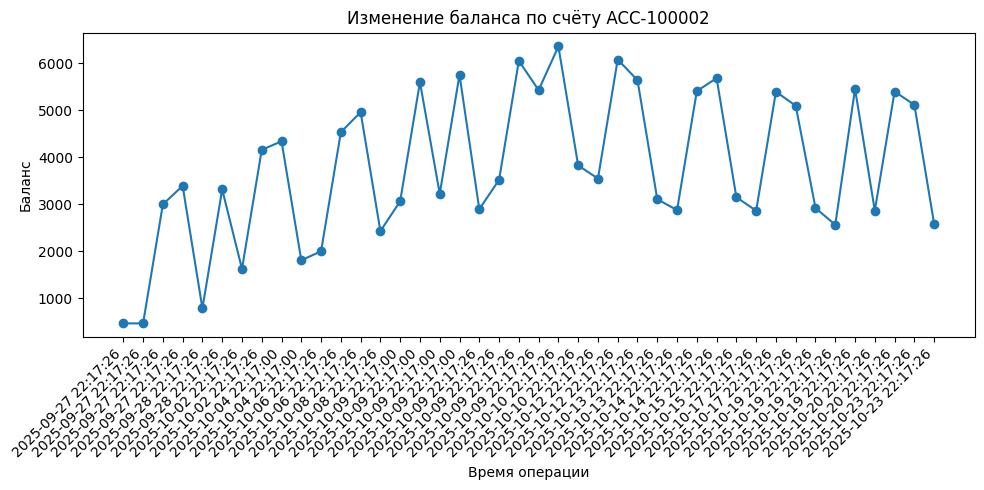

In [ ]:
# Загрузка "грязных" данных для SavingsAccount

savings_from_file = SavingsAccount("Test Saver", 0.0, account_number="ACC-100002")

print("Счёт для загрузки истории (Savings):", savings_from_file.account_number)

# 1. Загрузка истории из JSON
savings_from_file.load_history_from_file("files/transactions_dirty.json")

print("\n=== История SavingsAccount после загрузки из JSON ===")
savings_from_file.print_history()
print("\nБаланс SavingsAccount после загрузки из JSON:", savings_from_file.get_balance())

# 2. Дополнительная загрузка из CSV
savings_from_file.load_history_from_file("files/transactions_dirty.csv")

print("\n=== История SavingsAccount после загрузки JSON + CSV ===")
savings_from_file.print_history()
print("\nБаланс SavingsAccount после загрузки JSON + CSV:", savings_from_file.get_balance())

# 3. Визуализация динамики баланса
savings_from_file.plot_history()